<a href="https://colab.research.google.com/github/sarah-schayder/proc-imagens/blob/main/proc_imgs_tarefa6_sarah_schayder_25_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import skimage as ski
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
caminho = "/content/drive/MyDrive/processamento de imagens/imagens-tarefa-6/FIG334.TIF"

array([[29, 29, 29, ..., 29, 29, 29],
       [29, 29, 29, ..., 29, 29, 29],
       [29, 29, 29, ..., 29, 29, 29],
       ...,
       [30, 29, 29, ..., 41, 40, 41],
       [30, 29, 29, ..., 43, 43, 42],
       [30, 29, 29, ..., 41, 44, 44]], dtype=uint8)
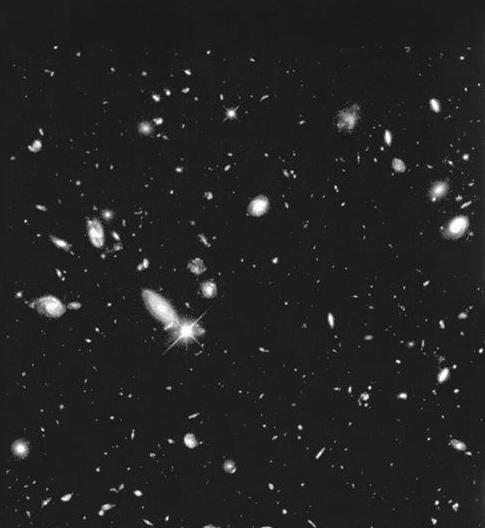

In [4]:
get_imagem = ski.io.imread(caminho)
get_imagem

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
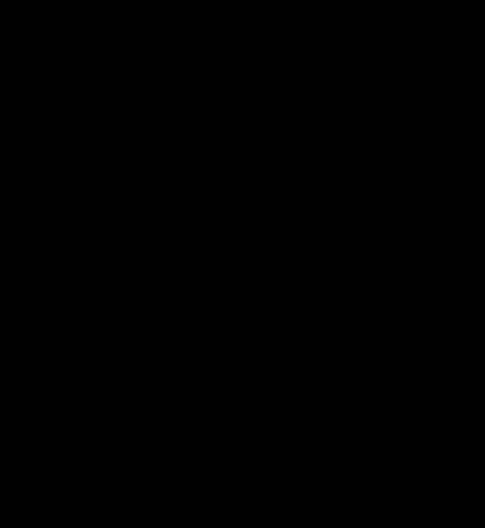

In [5]:
#fazendo uma mascara da imagem anterior
mascara = np.zeros(get_imagem.shape[:2], dtype="uint8")
mascara

In [6]:
w = np.ones((3, 3))
w = w / w.sum()

In [7]:
m, n = get_imagem.shape[:2]
m, n

(528, 485)

In [8]:
# Pegando as dimensões do kernel
k_m, k_n = w.shape

# Calculando o deslocamento horizontal e vertical
offset_m = k_m // 2
offset_n = k_n // 2

mascara_filtrada = np.zeros_like(get_imagem, dtype=np.float64)

for x in range(m):
    for y in range(n):
        soma = 0.0
        for i in range(k_m):
            for j in range(k_n):
                xi = x - offset_m + i
                yj = y - offset_n + j
                if xi >= 0 and xi < m and yj >= 0 and yj < n:
                    soma += w[i, j] * get_imagem[xi, yj]

        # Atribuindo a soma ao pixel correspondente na imagem filtrada
        mascara_filtrada[x, y] = soma

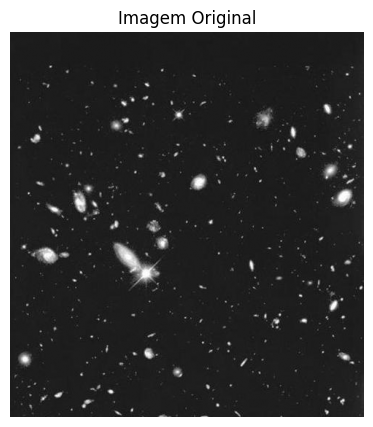

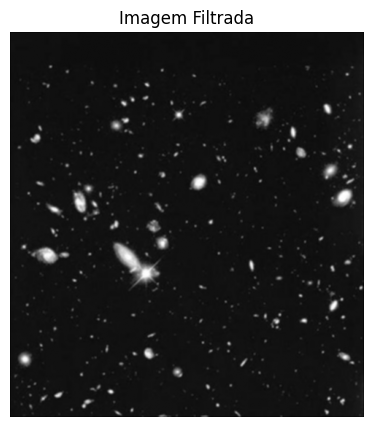

In [9]:
# Exibindo a imagem original
plt.figure(figsize=(5, 5))
plt.imshow(get_imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

# Exibindo a imagem filtrada
plt.figure(figsize=(5, 5))
plt.imshow(mascara_filtrada, cmap='gray')
plt.title('Imagem Filtrada')
plt.axis('off')
plt.show()

In [10]:
#Aplicando a limiarização através do hsitograma
limiar = ski.filters.threshold_otsu(mascara_filtrada)
binaria = np.where(mascara_filtrada > limiar, 255, 0).astype(np.uint8)

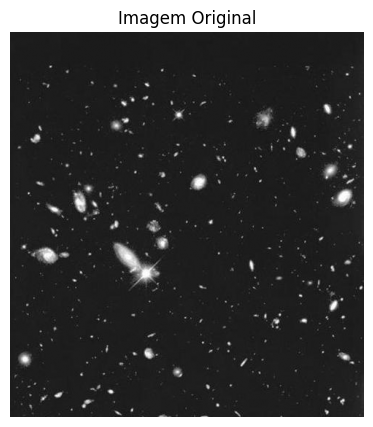

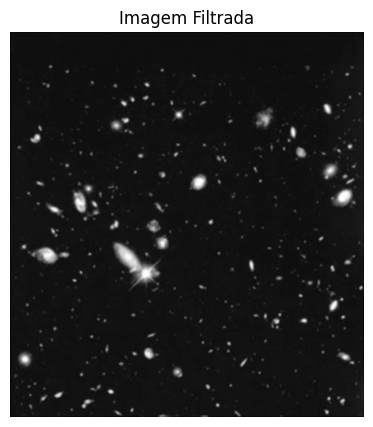

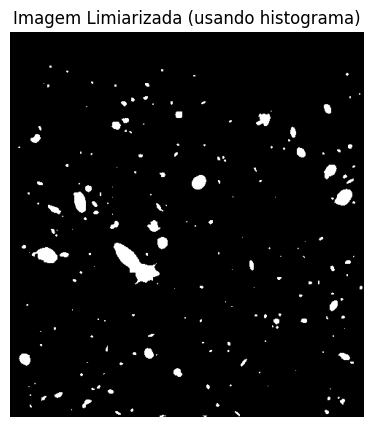

In [14]:
#plotando a imagem original
plt.figure(figsize=(5, 5))
plt.imshow(get_imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

#plotando a imagem filtrada
plt.figure(figsize=(5, 5))
plt.imshow(mascara_filtrada, cmap='gray')
plt.title('Imagem Filtrada')
plt.axis('off')
plt.show()

#plotando a imagem agora limiarizada
plt.figure(figsize=(5, 5))
plt.imshow(binaria, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Limiarizada (usando histograma)')
plt.axis('off')
plt.show()